# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Victor Alejandro Chavez Valadez"            # Tu nombre completo
MATRICULA = "81492"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Victor Alejandro Chavez Valadez
Matrícula: 81492
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\maryc\Desktop\UNI\Big data\Examen\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):**

El dataset se encuentra completamente limpio, sin presencia de valores nulos (0 valores faltantes en todas las columnas). La información abarca un periodo continuo de 21 años, desde el año 2000 hasta el 2020. Por último, la variable de estudio ('valor') es cuantitativa continua de tipo porcentaje, representando la proporción de adultos (15+) que consumieron alcohol en el último año, con un promedio global de aproximadamente 42.5% y valores que oscilan entre 0.83% y 85.06%.


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [ ]:
# Pregunta 1
filtro = config["filtro_paises"]
df_paises = df[df[filtro].notnull()].copy()

total_paises = df_paises["entity"].nunique()
print(f"Total de países distintos en el dataset: {total_paises}")

anio_reciente = df_paises["year"].max()

print(f"\n--- 10 Países con mayor consumo de alcohol ({anio_reciente}) ---")
top_10_mayor = (
    df_paises[df_paises["year"] == anio_reciente][["entity", "valor"]]
    .sort_values("valor", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print(top_10_mayor)

print(f"\n--- 10 Países con menor consumo de alcohol ({anio_reciente}) ---")
top_10_menor = (
    df_paises[df_paises["year"] == anio_reciente][["entity", "valor"]]
    .sort_values("valor", ascending=True)
    .head(10)
    .reset_index(drop=True)
)
print(top_10_menor)

Total de países distintos en el dataset: 189

--- 10 Países con mayor consumo de alcohol (2020) ---
        entity      valor
0   Luxembourg  84.195100
1      Ireland  83.209274
2      Andorra  82.505775
3    Australia  80.670130
4  New Zealand  80.278630
5  Switzerland  79.957200
6      Austria  79.401760
7      Iceland  79.204660
8      Germany  78.830920
9      Denmark  78.287570

--- 10 Países con menor consumo de alcohol (2020) ---
         entity     valor
0        Kuwait  0.830784
1       Somalia  0.922955
2       Comoros  0.952743
3         Yemen  1.152923
4         Libya  1.258470
5         Syria  1.496604
6          Iran  1.545203
7      Pakistan  1.574980
8    Mauritania  1.743128
9  Saudi Arabia  1.869912


**Interpretación:**

Se identificaron 189 países reales tras descartar las entidades regionales y agregados que carecen de código ISO. Al analizar los valores extremos en el año más reciente con datos del 2020, se evidencia una notable polarización geográfica y sociocultural:

- Mayor consumo: Empezando por países europeos y de Oceanía como Luxemburgo (84.2%), Irlanda (83.2%), Andorra (82.5%) y Australia (80.7%), donde el consumo de bebidas alcohólicas es muy comun en estos paises integrandolas a su vida social y cultural.

- Menor consumo: comenzando por naciones de Medio Oriente y África como Kuwait (0.83%), Somalia (0.92%), Comoras (0.95%) y Yemen (1.15%), lo cual responde directamente a que estos paises no estan comun en esto paises.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [38]:
# Pregunta 2
paises_p2 = ["Mexico", "United States"]
df_p2 = df_paises[df_paises["entity"].isin(paises_p2)].copy()

anios_mex = set(df_p2[df_p2["entity"] == "Mexico"]["year"])
anios_usa = set(df_p2[df_p2["entity"] == "United States"]["year"])
anios_comunes = sorted(list(anios_mex.intersection(anios_usa)))
anio_min, anio_max = anios_comunes[0], anios_comunes[-1]

print(f"Rango de años disponible para ambos países: {anio_min} a {anio_max}")

df_p2_filtrado = (
    df_p2[(df_p2["year"] >= anio_min) & (df_p2["year"] <= anio_max)]
    .sort_values(by=["year", "entity"])
    .reset_index(drop=True)
)
df_p2_filtrado

Rango de años disponible para ambos países: 2000 a 2020


,entity,code,year,valor
0,Mexico,MEX,2000,43.696823
1,United States,USA,2000,69.076190
2,Mexico,MEX,2001,43.486710
3,United States,USA,2001,69.189320
4,Mexico,MEX,2002,43.310062
5,United States,USA,2002,69.332360
6,Mexico,MEX,2003,43.456112
7,United States,USA,2003,69.532560
8,Mexico,MEX,2004,43.573890
9,United States,USA,2004,69.782265


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [47]:
# Pregunta 3
paises_5 = ["Mexico", "Spain", "Japan", "South Africa", "Australia"]
anio_reciente = df_paises["year"].max()

df_p3 = (
    df_paises[(df_paises["entity"].isin(paises_5)) & (df_paises["year"] == anio_reciente)][["entity", "valor"]]
    .sort_values("valor", ascending=False)
    .reset_index(drop=True)
)
print(f"Comparación de 5 países en el año más reciente ({anio_reciente}):")
print(df_p3)

mas_alto = df_p3.iloc[0]
mas_bajo = df_p3.iloc[-1]
diferencia = mas_alto["valor"] - mas_bajo["valor"]

print(f"\nPaís con el valor más alto: {mas_alto['entity']} ({mas_alto['valor']:.2f}%)")
print(f"País con el valor más bajo: {mas_bajo['entity']} ({mas_bajo['valor']:.2f}%)")
print(f"Diferencia entre ambos: {diferencia:.2f} puntos porcentuales")

Comparación de 5 países en el año más reciente (2020):
         entity      valor
0     Australia  80.670130
1         Spain  76.592570
2         Japan  67.500060
3        Mexico  42.036960
4  South Africa  29.618544

País con el valor más alto: Australia (80.67%)
País con el valor más bajo: South Africa (29.62%)
Diferencia entre ambos: 51.05 puntos porcentuales


**Interpretación:**

Al comparar 5 países de continentes distintos en el año 2020, encontramos contrastes sustanciales:
- El valor más alto lo tiene Australia (Oceanía) con un 80.67%, seguido de cerca por España (Europa) con 76.59% y **Japón (Asia) con 67.50%.
- Por otro lado, México (América) se ubica en un nivel medio con 42.04%, mientras que el valor más bajo corresponde a Sudáfrica (África) con un 29.62%.
- La diferencia absoluta entre el país más alto y el más bajo es de 51.05 puntos porcentuales, evidenciando la gran brecha de prevalencia de consumo entre países desarrollados con hábitos arraigados y naciones en vías de desarrollo.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [46]:
# Pregunta 4
anio_reciente = df_paises["year"].max()

latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

df_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)]
df_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)]

prom_latam = df_latam["valor"].mean()
prom_asia = df_asia["valor"].mean()

print(f"--- Promedios de consumo en {anio_reciente} ---")
print(f"Latinoamérica: {prom_latam:.2f}%")
print(f"Asia: {prom_asia:.2f}%")

--- Promedios de consumo en 2020 ---
Latinoamérica: 51.31%
Asia: 60.49%


**Interpretación:**

Al comparar ambos grupos en el año 2020, el grupo de Asia tuvo un promedio mayor con 60.49%, mientras que Latinoamérica tuvo un promedio de 51.31%.

En Latinoamérica destaca Argentina con un consumo alto de 71.02%, mientras que México y Colombia están más abajo rondando el 41% y 42%. Por su parte, en el grupo de Asia los tres países se mantienen más parejos y todos por encima del 50%, teniendo a Japón con el valor más alto (67.50%).

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [45]:
# Pregunta 5
pais_elegido = "Argentina"
df_pais = df_paises[df_paises["entity"] == pais_elegido].sort_values("year").reset_index(drop=True)

max_fila = df_pais.loc[df_pais["valor"].idxmax()]
min_fila = df_pais.loc[df_pais["valor"].idxmin()]

print(f"--- Análisis de tendencia temporal para {pais_elegido} (2000 - 2020) ---")
print(f"Año con valor MÁXIMO: {int(max_fila['year'])} con {max_fila['valor']:.2f}%")
print(f"Año con valor MÍNIMO: {int(min_fila['year'])} con {min_fila['valor']:.2f}%")

--- Análisis de tendencia temporal para Argentina (2000 - 2020) ---
Año con valor MÁXIMO: 2015 con 71.68%
Año con valor MÍNIMO: 2003 con 67.38%


**Interpretación:**

Para Argentina, el porcentaje de personas que consumieron alcohol tuvo su valor más alto en el año 2015 con un 71.68%, y su valor más bajo en el 2003 con un 67.38%.

La tendencia general a lo largo del tiempo es **fluctuante con tendencia al alza**: empezó con una ligera caída del 2000 al 2003 hasta tocar su mínimo, pero a partir de ahí comenzó a subir de forma constante hasta alcanzar su máximo en 2015, y en los últimos años se ha mantenido bastante estable alrededor del 71%.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [44]:
# Pregunta 6
df_mex = df_paises[df_paises["entity"] == "Mexico"].sort_values("year").reset_index(drop=True)

anio_inicial = df_mex["year"].min()
anio_final = df_mex["year"].max()

valor_inicial = df_mex.loc[df_mex["year"] == anio_inicial, "valor"].values[0]
valor_final = df_mex.loc[df_mex["year"] == anio_final, "valor"].values[0]

cambio_pct = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"Consumo en México en {anio_inicial}: {valor_inicial:.2f}%")
print(f"Consumo en México en {anio_final}: {valor_final:.2f}%")
print(f"Cambio porcentual: {cambio_pct:.2f}%")

Consumo en México en 2000: 43.70%
Consumo en México en 2020: 42.04%
Cambio porcentual: -3.80%


**Interpretación:**

Para México se presentó una **caída relativa de -3.80%** entre el año 2000 y el 2020 (pasó de 43.70% a 42.04%).

En mis palabras, creo que esta ligera disminución se debe a que justo en el 2020 inició la pandemia de COVID-19 y el confinamiento, lo que ocasionó el cierre de bares, antros, restaurantes y reuniones sociales donde normalmente se consume alcohol, e incluso hubo periodos de ley seca en varias ciudades. También han influido las campañas de concientización de salud y programas como el alcoholímetro, aunque la reducción fue pequeña porque el hábito de consumo sigue siendo muy arraigado.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [43]:
# Pregunta 7
anio_reciente = df_paises["year"].max()

valores_recientes = df_paises[df_paises["year"] == anio_reciente]["valor"].to_numpy()

valores_limpios = valores_recientes[~np.isnan(valores_recientes)]

media = np.mean(valores_limpios)
mediana = np.median(valores_limpios)
desv_std = np.std(valores_limpios)

print(f"--- Estadísticas descriptivas con NumPy ({anio_reciente}) ---")
print(f"Media: {media:.2f}%")
print(f"Mediana: {mediana:.2f}%")
print(f"Desviación estándar: {desv_std:.2f}%")

--- Estadísticas descriptivas con NumPy (2020) ---
Media: 42.25%
Mediana: 42.04%
Desviación estándar: 24.00%


**Interpretación:**

Para el año 2020, usando NumPy se obtuvieron los siguientes resultados:
- **Media:** 42.25%
- **Mediana:** 42.04%
- **Desviación estándar:** 24.00%

Al ver que la media y la mediana son prácticamente idénticas (alrededor del 42%), indica que los datos globales están bastante centrados, y de hecho México (con 42.04%) se encuentra exactamente en la mediana mundial. Sin embargo, la desviación estándar de 24.00% es bastante alta, lo que nos confirma que hay una gran dispersión en el mundo: los países están muy separados entre los que casi no consumen alcohol (menos de 5%) y los que tienen consumos muy altos (más de 80%).

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

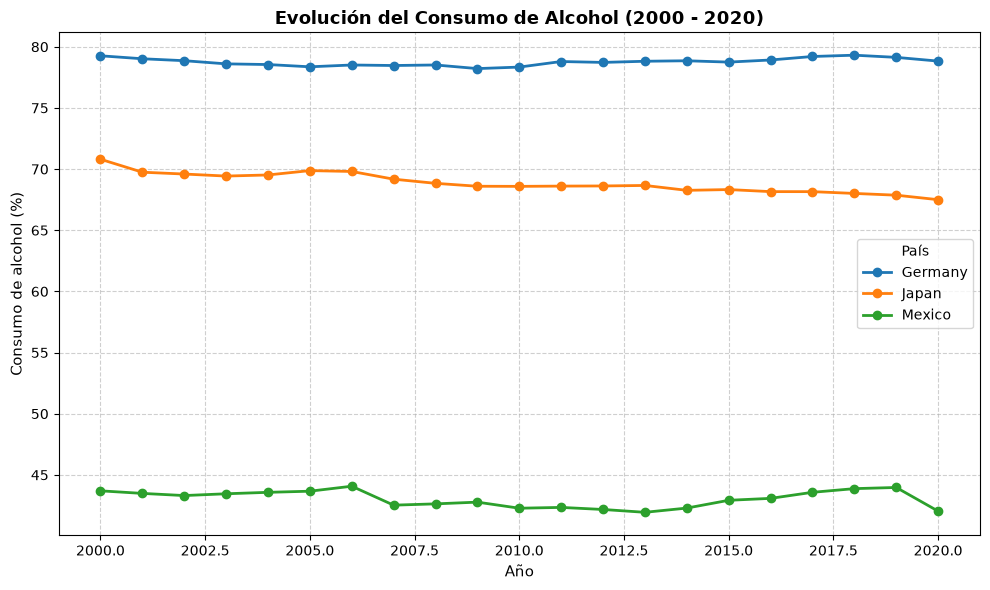

In [42]:
# Pregunta 8
paises_grafica = ["Germany", "Japan", "Mexico"]

plt.figure(figsize=(10, 6))

for pais in paises_grafica:
    datos_pais = df_paises[df_paises["entity"] == pais].sort_values("year")
    plt.plot(datos_pais["year"], datos_pais["valor"], marker="o", linewidth=2, label=pais)

plt.title("Evolución del Consumo de Alcohol (2000 - 2020)", fontsize=13, fontweight="bold")
plt.xlabel("Año", fontsize=11)
plt.ylabel(f"Consumo de alcohol ({config['unidad']})", fontsize=11)
plt.legend(title="País")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretación:**

En la gráfica se comparó la evolución a lo largo del tiempo de 3 países de distintos continentes: **Alemania**, **Japón** y **México**:
- Se aprecian tres niveles muy claros y bien diferenciados: Alemania se mantiene en la parte más alta de forma casi constante entre el 78% y el 79% (lo cual coincide con su fuerte cultura cervecera), Japón se ubica en un nivel intermedio que fue bajando poco a poco de 70.81% a 67.50%, y México se encuentra bastante más abajo de ambos, moviéndose entre el 42% y el 44%.
- La tendencia general muestra que mientras Alemania se mantuvo prácticamente plana durante los 21 años, tanto Japón como México tuvieron una ligera disminución hacia el 2020.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

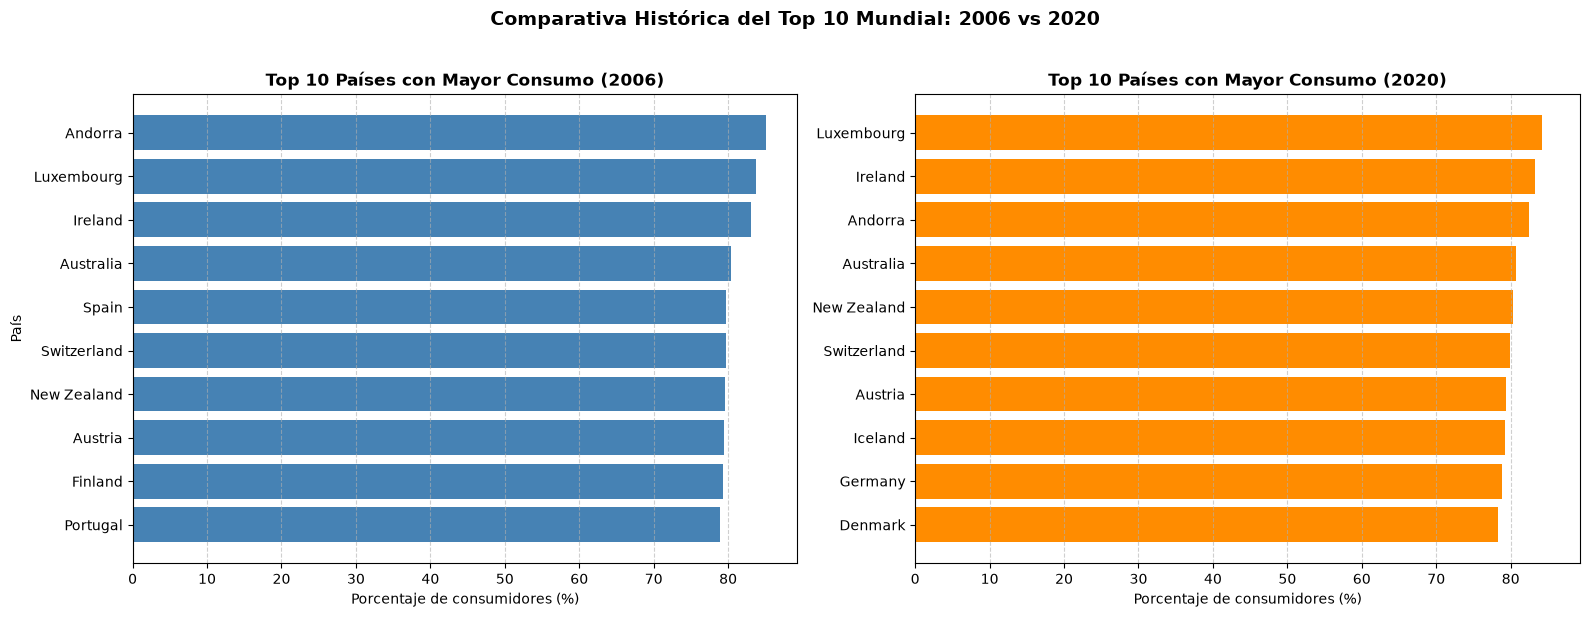

In [41]:
# Pregunta 9
anio_nacimiento = 2006
anio_reciente = df_paises["year"].max()

top_nacimiento = (
    df_paises[df_paises["year"] == anio_nacimiento]
    .sort_values("valor", ascending=False)
    .head(10)
)

top_reciente = (
    df_paises[df_paises["year"] == anio_reciente]
    .sort_values("valor", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Gráfica 1: Año de nacimiento (2006)
axes[0].barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
axes[0].set_title(f"Top 10 Países con Mayor Consumo ({anio_nacimiento})", fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"Porcentaje de consumidores ({config['unidad']})")
axes[0].set_ylabel("País")
axes[0].invert_yaxis()
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# Gráfica 2: Año más reciente (2020)
axes[1].barh(top_reciente["entity"], top_reciente["valor"], color="darkorange")
axes[1].set_title(f"Top 10 Países con Mayor Consumo ({anio_reciente})", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"Porcentaje de consumidores ({config['unidad']})")
axes[1].set_ylabel("")
axes[1].invert_yaxis()
axes[1].grid(axis="x", linestyle="--", alpha=0.6)

plt.suptitle(f"Comparativa Histórica del Top 10 Mundial: {anio_nacimiento} vs {anio_reciente}", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**

Al comparar el Top 10 del año en que nací (2006) contra el año más reciente disponible (2020, ya que el dataset de alcohol no tiene datos de 2023), se notan varios cambios importantes:
- El primer lugar cambió: en 2006 Andorra era el país con mayor consumo con un 85.06%, pero para el 2020 bajó al tercer lugar con 82.51%, quedando arriba Luxemburgo (84.20%) e Irlanda (83.21%).
- Varios países se mantuvieron casi idénticos durante esos 14 años, como Australia, Nueva Zelanda, Suiza y Austria, todos rondando el 80%.
- Países como España (79.74%), Finlandia (79.25%) y Portugal (78.92%) salieron del Top 10 para el 2020, y en su lugar entraron Islandia (79.20%), Alemania (78.83%) y Dinamarca (78.29%).

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

A lo largo de este análisis aprendí que el consumo de alcohol presenta patrones geográficos y culturales muy claros: los países europeos y de altos ingresos lideran el consumo mundial por encima del 80% debido a una fuerte aceptación social, mientras que naciones de Medio Oriente y África registran consumos mínimos menores al 2% por normas religiosas y prohibiciones legales. Por su parte, México se mantuvo en un punto intermedio bastante estable rondando el 42% y 43%.

Como limitación principal del dataset, solo mide si la persona bebió alcohol al menos una vez en el año, pero no nos dice la frecuencia ni la cantidad de litros consumidos (no distingue entre tomarse una cerveza al año o beber con frecuencia). Además, la información concluye en 2020, por lo que no permite observar la recuperación postpandemia. Si tuviera más tiempo, me gustaría cruzar estos datos con variables como el PIB o la esperanza de vida, y desglosarlo por género para comparar las diferencias de consumo entre hombres y mujeres.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
